In [1]:
"""
-- Identify border and non-border router---
1. Group Public ASN and Private ASN hosts 
2. Border router: Public ASN with interface IPs associated with more than one ASN.
3. Non-border with public ASN router: Public ASN with interface IPs associated with only one ASN.
4. Non-border with non-public ASN router: Public ASN with interface IPs associated with only one ASN.


-- Identify core and non-core routers----
1. No. of IP interfaces
2. No. of ASes connected.
"""
    

'\n-- Identify border and non-border router---\n1. Group Public ASN and Private ASN hosts \n2. Border router: Public ASN with interface IPs associated with more than one ASN.\n3. Non-border with public ASN router: Public ASN with interface IPs associated with only one ASN.\n4. Non-border with non-public ASN router: Public ASN with interface IPs associated with only one ASN.\n\n\n-- Identify core and non-core routers----\n1. No. of IP interfaces\n2. No. of ASes connected.\n'

In [1]:
import pandas as pd
df = pd.read_csv ("results/open_keepalive_notification_only_02_feb_bonaire_router_mapping.csv")
df

/tmp/ipykernel_24341/1905998813.py:2: DtypeWarning: Columns (3,4,5,28) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv ("results/open_keepalive_notification_only_02_feb_bonaire_router_mapping.csv")


,Unnamed: 0.1,Unnamed: 0,target_ip,tcp_connected,bgp_responded,tcp_reset,tcp_latency,bgp_latency,bgp_response_type,outcome,...,opt_params_raw,opt_params,error_code,error_subcode,date,is_non_public_asn,asn_from_bgp_id,effective_asn,router_key,tags_honeypot
0,706980.0,707136.0,80.254.77.15,True,True,False,0.017,0.018,bgp_open_received,bgp_responded,...,0212010400010001010400020001410400006139,"MP, MP, AS4",NaN,NaN,2026-02-06T22:12:06.192228,False,24889.0,24889.0,80.254.77.15_24889,NaN
1,1825923.0,1826364.0,34.135.160.215,True,True,False,0.103,0.104,bgp_open_received,bgp_responded,...,0212010400010001010400020001410400004f1d,"MP, MP, AS4",NaN,NaN,2026-02-07T08:10:26.832208,False,NaN,20253.0,1.2.3.4_20253,NaN
2,2316499.0,2317069.0,103.150.44.10,True,True,False,0.183,0.625,bgp_open_received,bgp_responded,...,0212010400010001010400020001410400022464,"MP, MP, AS4",NaN,NaN,2026-02-07T12:34:29.545459,False,140388.0,140388.0,103.150.44.10_140388,NaN
3,2343773.0,2344350.0,70.34.199.30,True,True,False,0.025,0.026,bgp_open_received,bgp_responded,...,023c010400010001010400020001020041040000fc3c46...,"MP, MP, RR, AS4, ERR, 64, 69, 73",NaN,NaN,2026-02-07T12:49:06.656337,True,NaN,64572.0,10.159.64.221_64572,NaN
4,2350635.0,2351215.0,35.184.21.78,True,True,False,0.103,0.111,bgp_open_received,bgp_responded,...,0212010400010001010400020001410400004f1d,"MP, MP, AS4",NaN,NaN,2026-02-07T12:53:24.887505,False,NaN,20253.0,1.2.3.4_20253,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
141308,NaN,NaN,103.166.251.97,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,False,NaN,142153.0,10.80.80.33_142153,False
141309,NaN,NaN,103.155.27.172,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,True,153038.0,153038.0,103.155.27.172_153038,False
141310,NaN,NaN,152.231.18.253,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,True,NaN,65220.0,10.220.220.1_65220,False
141311,NaN,NaN,103.104.142.225,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,True,19281.0,19281.0,9.9.9.9_19281,False


In [3]:
import pandas as pd
# For private_asns: make router key has router_id_private_asn_asn_from_target_ip
private_asn_df = pd.read_csv("results/private_asn_ips.csv")
private_asn_df.columns
private_asn_df["router_key"] = (
    private_asn_df["router_key"].astype(str) + "_" + private_asn_df["asn_from_target_ip"].astype(str)
)
private_asn_df["effective_asn"] = private_asn_df["asn_from_target_ip"]
private_asn_df.to_csv("results/private_asn_ips_v2.csv")

In [4]:
private_asn_df

,target_ip,date,router_key,tags_honeypot,router_id,asn,is_non_public_asn,effective_asn,asn_from_router_id,router_id_is_private,asn_from_target_ip
0,70.34.199.30,2026-02-07T12:49:06.656337,10.159.64.221_64572_20473.0,NaN,10.159.64.221,6.457200e+04,True,20473.0,NaN,True,20473.0
1,128.22.57.22,2026-02-06T15:48:36.607850,10.48.70.48_64540_17511.0,NaN,10.48.70.48,6.454000e+04,True,17511.0,NaN,True,17511.0
2,38.156.22.200,2026-02-06T15:48:36.803323,172.20.255.1_65000_64134.0,NaN,172.20.255.1,6.500000e+04,True,64134.0,NaN,True,64134.0
3,36.255.200.38,2026-02-06T15:48:36.239162,10.160.26.236_23456_134927.0,NaN,10.160.26.236,2.345600e+04,True,134927.0,NaN,True,134927.0
4,216.25.49.2,2026-02-06T15:48:36.884168,10.212.0.11_23456_399356.0,NaN,10.212.0.11,2.345600e+04,True,399356.0,NaN,True,399356.0
...,...,...,...,...,...,...,...,...,...,...,...
50845,162.208.89.180,NaN,162.208.89.180_55016_55016.0,False,162.208.89.180,4.212346e+09,True,55016.0,55016.0,False,55016.0
50846,152.231.17.233,NaN,152.231.20.11_52505_52505.0,False,152.231.20.11,6.512100e+04,True,52505.0,52505.0,False,52505.0
50847,177.152.53.17,NaN,177.152.52.42_61912_61912.0,False,177.152.52.42,6.553000e+04,True,61912.0,61912.0,False,61912.0
50848,103.155.27.172,NaN,103.155.27.172_153038_153038.0,False,103.155.27.172,6.510200e+04,True,153038.0,153038.0,False,153038.0


In [1]:
# Find border router
import pandas as pd

# Load public ASN data
public_asn_df = pd.read_csv("results/public_asn_ips.csv")

# All public target IPs
all_public_target_ips = public_asn_df["target_ip"].dropna().unique()

# Avoid counting ASN present in BGP OPEN
filtered = public_asn_df[public_asn_df["asn_from_target_ip"] != public_asn_df["asn"]]

# Count unique connected ASNs per border router
asn_counts = (
    filtered.groupby("router_key")["asn_from_target_ip"]
    .nunique()
    .reset_index(name="unique_asn_count")
)

# Border routers (more than 1 ASN)
border_router_public = asn_counts[asn_counts["unique_asn_count"] > 1]
num_border_routers = len(border_router_public)
print(f"{num_border_routers} are border.")

# Find the ASes connected by each border_router_public
border_routers = border_router_public["router_key"]

# Gives connected ASes of border router 
# E.g. 0.0.0.0_56258    [56258.0, 58463.0, 149696.0]
covered_asns_per_router = (
    public_asn_df[public_asn_df["router_key"].isin(border_routers)]
    .groupby("router_key")["asn_from_target_ip"]
    .unique()
)

covered_asns_union = set().union(*covered_asns_per_router.values)
print(f"The border routers connect {len(covered_asns_union)} ASNs.")


managing_asns_per_router = (
    public_asn_df[public_asn_df["router_key"].isin(border_routers)]
    .groupby("router_key")["asn"]
    .unique()
)

border_managing_asns_union = set().union(*managing_asns_per_router.values)
border_public_managing_asns = list(border_managing_asns_union)

print(f"The border routers are managed by {len(border_public_managing_asns)} ASNs.")

# Border router target IPs
border_public_target_ips = public_asn_df[
    public_asn_df["router_key"].isin(border_router_public["router_key"])
]["target_ip"].dropna().unique()


print(f"There are {len(border_public_target_ips)} border router target IPs.")


1127 are border.
The border routers connect 1496 ASNs.
The border routers are managed by 729 ASNs.
There are 20038 border router target IPs.


In [2]:
# Non border public ASN
non_border_router_public = asn_counts[asn_counts["unique_asn_count"] == 1]
num_non_border_public_routers = len(non_border_router_public)
print(f"{num_non_border_public_routers} are non-border with public ASN.")

# Find the ASes connected by each non_border_router_public
non_border_public_routers = non_border_router_public["router_key"]

managing_asns_per_router = (
    public_asn_df[public_asn_df["router_key"].isin(non_border_public_routers)]
    .groupby("router_key")["asn"]
    .unique()
)

non_border_managing_asns_union = set().union(*managing_asns_per_router.values)
non_border_public_managing_asns = list(non_border_managing_asns_union)

print(f"The non-border public ASN routers are managed by {len(non_border_public_managing_asns)} ASNs.")

# Find target_ip corresponding to non-border routers
# Non-border router target IPs: everything else
non_border_public_target_ips = list(set(all_public_target_ips) - set(border_public_target_ips))
print(f"There are {len(non_border_public_target_ips)} non-border public router target IPs.")


3181 are non-border with public ASN.
The non-border public ASN routers are managed by 1427 ASNs.
There are 70425 non-border public router target IPs.


In [3]:
# Non border private ASN
private_asn_df = pd.read_csv("results/private_asn_ips_v2.csv")
non_border_private_routers = private_asn_df["router_key"]
print(f"{non_border_private_routers.nunique()} are non-border routers with private ASN.")
non_border_private_managing_asns = private_asn_df["asn_from_target_ip"].dropna().unique()
print(f"The non-border private ASN routers are managed by {len(non_border_private_managing_asns)} ASNs.")

non_border_private_target_ips = (
    private_asn_df["target_ip"]
    .dropna()
    .unique()
)


print(f"There are {len(non_border_private_target_ips)} non-border private router target IPs.")

16124 are non-border routers with private ASN.
The non-border private ASN routers are managed by 2553 ASNs.
There are 50850 non-border private router target IPs.


In [4]:
all_managing_asns = list(set(border_public_managing_asns) | set(non_border_public_managing_asns) | set(non_border_private_managing_asns))
print(f"Those exposed routers are associated with {len(all_managing_asns)} ASNs")

Those exposed routers are associated with 4194 ASNs


In [5]:
all_ips = set(public_asn_df["target_ip"]) | set(private_asn_df["target_ip"])
len(all_ips)

141313

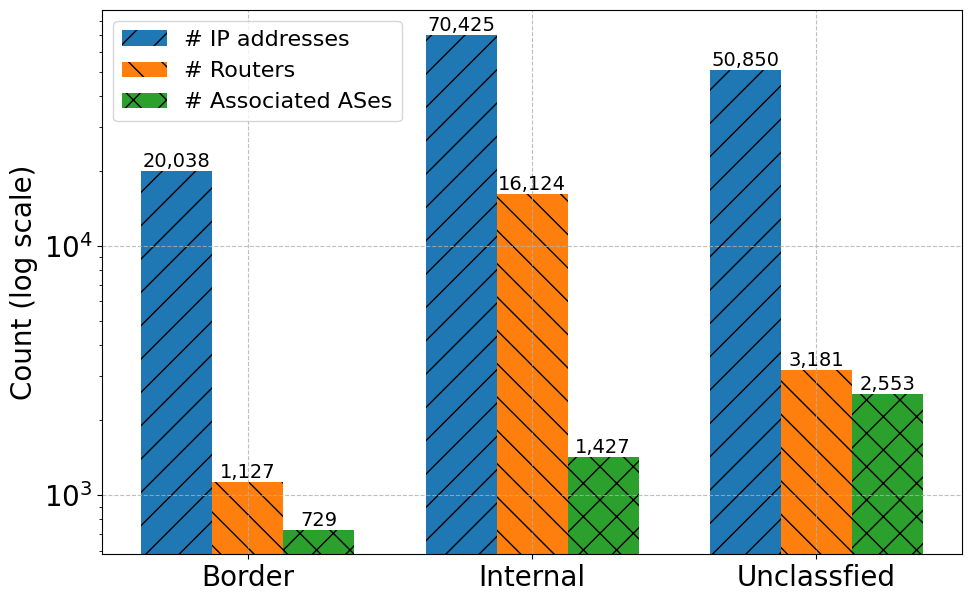

In [6]:
# Plot of # IPs, # routers, and # managing ASNs.
import pandas as pd
import matplotlib.pyplot as plt

# ---------- IEEE-style global settings ----------
plt.rcParams.update({
    'font.size': 16,
    'axes.labelsize': 20,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
})
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
# --- Load data ---

# --- Compute counts for plotting ---
groups = ["Border", "Internal", "Unclassfied"]

# Number of routers
num_routers = [
    len(border_routers),
    non_border_private_routers.nunique(),
    len(non_border_public_routers)
]

# Number of IPs (target_ip)
num_ips = [
    len(border_public_target_ips), len(non_border_public_target_ips), len(non_border_private_routers)
]

# Number of ASNs (number of asn_from_target_ip for non-public ASNs)
num_asns = [
    len(border_public_managing_asns), len(non_border_public_managing_asns), len(non_border_private_managing_asns)
]

# --- Create a bar plot ---
import numpy as np

x = np.arange(len(groups))
width = 0.25

# Hatches for visual distinction
hatches = ['/', '\\', 'x']

fig, ax = plt.subplots(figsize=(10,6.3))

# Bars with hatches
bars1 = ax.bar(x - width, num_ips, width, label="# IP addresses", hatch=hatches[0])
bars2 = ax.bar(x, num_routers, width, label="# Routers", hatch=hatches[1])
bars3 = ax.bar(x + width, num_asns, width, label="# Associated ASes", hatch=hatches[2])

# --- Bars with numbers on top ---
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,  # X position: center of bar
            height,                             # Y position: top of bar
            f'{int(height):,}',                 # Text with commas
            ha='center', va='bottom', fontsize=14
        )

# Labels and title
ax.set_xticks(x)
ax.set_xticklabels(groups, rotation=0)
ax.set_ylabel("Count (log scale)")
ax.set_yscale('log')  # Logarithmic y-axis
# ax.set_title("Comparison of Routers, IPs, and ASNs by Group with Hatches")
ax.legend(loc='upper left', ncols = 1)
ax.grid(axis='both', linestyle='--', alpha=0.8)

plt.tight_layout()
plt.savefig("images/border_non_border_ips_asns_routers.pdf")
plt.show()

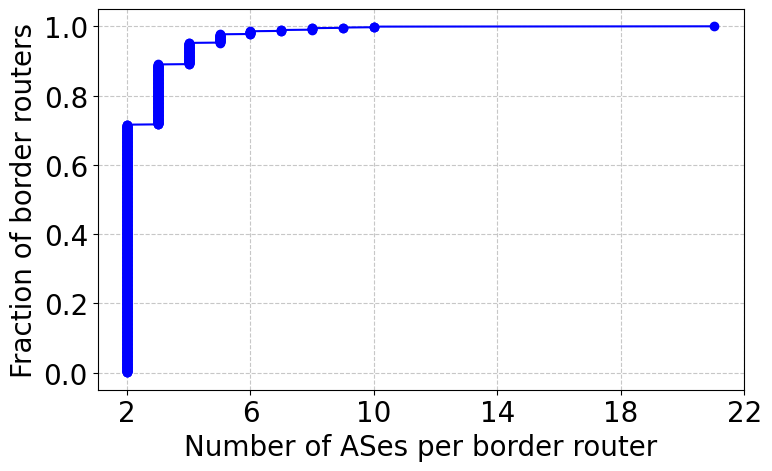

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Sort counts for CDF
counts = np.sort(border_router_public["unique_asn_count"])
cdf = np.arange(1, len(counts)+1) / len(counts)

# Plot
plt.figure(figsize=(8,5))
plt.plot(counts, cdf, marker='o', linestyle='-', color='blue')
plt.xlabel("Number of ASes per border router")
plt.ylabel("Fraction of border routers")
# Force integer x-ticks
plt.xticks(np.arange(int(counts.min()), int(counts.max())+4, 4))


# plt.title("CDF of Number of ASes per Border Router (Public)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("images/cdf_ases_per_border_router.pdf")
plt.show()

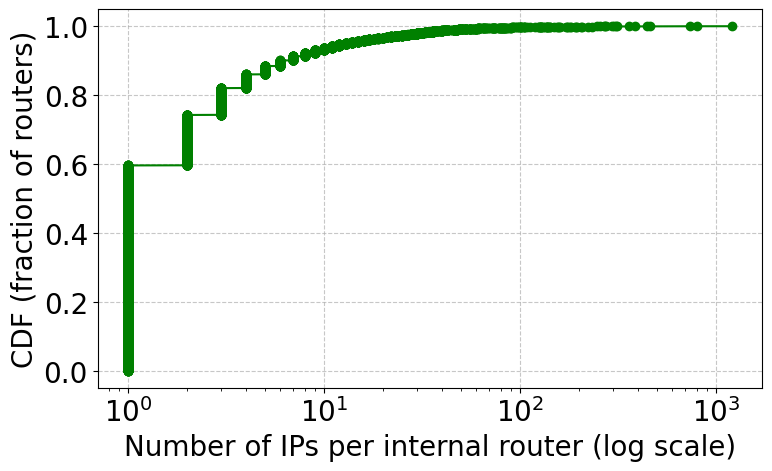

In [8]:
# CDFs of IPs per router for non-private routers
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Combine public and private non-border routers ---
df_public = public_asn_df[public_asn_df["router_key"].isin(non_border_public_routers)]
df_private = private_asn_df  # assuming all rows are non-border private routers

# Merge into a single DataFrame
df_non_border = pd.concat([df_public, df_private], ignore_index=True)

df_border = public_asn_df[public_asn_df["router_key"].isin(border_routers)]

# Count unique IPs per router
ips_per_router = df_non_border.groupby("router_key")["target_ip"].nunique()

# Sort counts for CDF
counts = np.sort(ips_per_router.values)
cdf = np.arange(1, len(counts)+1) / len(counts)

# --- Plot the CDF ---
plt.figure(figsize=(8,5))
plt.plot(counts, cdf, marker='o', linestyle='-', color='green', label="Non-border Routers")

plt.xlabel("Number of IPs per internal router (log scale)")
plt.ylabel("CDF (fraction of routers)")
# plt.title("CDF of IPs per Non-Border Router")
plt.xscale("log")  # log scale for clarity
plt.grid(True, linestyle='--', alpha=0.7)
# plt.legend()
plt.tight_layout()
plt.savefig("images/ips_per_internal_router.pdf")
plt.show()

In [10]:
# Verify whether the grouping of our IPs to a router is valid. based on optional params
df_orig_bgp_scan = pd.read_csv("data/bgp_scan_results_02_feb_bonaire.csv")

In [18]:
# Another appraoch is by comparing tcp_latncy and bgp_latency
"""

"""
import pandas as pd

# Merge df_non_border with BGP scan latencies
df_merged_orig_non_border = pd.merge(
    df_non_border,
    df_orig_bgp_scan[['target_ip', 'tcp_latency', 'bgp_latency']],
    on='target_ip',
    how='left'
)

# Group by router_key and compute latency stats
latency_stats = df_merged_orig_non_border.groupby('router_key').agg(
    tcp_min=('tcp_latency', 'min'),
    tcp_max=('tcp_latency', 'max'),
    tcp_mean=('tcp_latency', 'mean'),
    tcp_std=('tcp_latency', 'std'),
    bgp_min=('bgp_latency', 'min'),
    bgp_max=('bgp_latency', 'max'),
    bgp_mean=('bgp_latency', 'mean'),
    bgp_std=('bgp_latency', 'std'),
    count=('target_ip', 'count')
).reset_index()

# Compute latency differences
latency_stats['tcp_diff'] = latency_stats['tcp_max'] - latency_stats['tcp_min']
latency_stats['bgp_diff'] = latency_stats['bgp_max'] - latency_stats['bgp_min']

# Set thresholds as 95th percentile of observed differences
tcp_threshold = latency_stats['tcp_diff'].quantile(0.95)
bgp_threshold = latency_stats['bgp_diff'].quantile(0.95)
print("95th percentile TCP difference:", tcp_threshold)
print("95th percentile BGP difference:", bgp_threshold)

# Flag routers with unusually high latency variation
latency_stats['tcp_large_variation'] = latency_stats['tcp_diff'] > tcp_threshold
latency_stats['bgp_large_variation'] = latency_stats['bgp_diff'] > bgp_threshold

# Display routers with large variation
extreme_variation = latency_stats[latency_stats['tcp_large_variation'] | latency_stats['bgp_large_variation']]
print(extreme_variation[['router_key', 'tcp_diff', 'bgp_diff', 'count']])

# Optional summary
print("Number of routers with extreme TCP variation:", extreme_variation['tcp_large_variation'].sum())
print("Number of routers with extreme BGP variation:", extreme_variation['bgp_large_variation'].sum())

95th percentile TCP difference: 0.044
95th percentile BGP difference: 0.04500000000000001
                       router_key  tcp_diff  bgp_diff  count
24        1.0.0.111_13335_17557.0     0.205     0.214      8
27         1.0.0.1_13335_138123.0     0.060     0.055     92
28                 1.1.1.1_132856     0.163     0.060      8
38           1.1.1.1_13335_4538.0     0.056     0.058      4
41          1.1.1.1_13335_55410.0     0.052     0.053     10
...                           ...       ...       ...    ...
19292          97.107.34.16_30269     0.001     0.121     32
19300         98.96.218.128_21859     0.113     0.078    160
19301  98.98.100.11_21859_21859.0     0.068     0.075     70
19302  98.98.100.12_21859_21859.0     0.036     0.097     38
19303  98.98.12.146_21859_21859.0     0.074     0.085      6

[1294 rows x 4 columns]
Number of routers with extreme TCP variation: 962
Number of routers with extreme BGP variation: 957


In [12]:
# Border and Non-border router exposure across ASes
# 1. Count routers per ASN

# 1. Count border and non-border routers
border_counts = df_border.groupby('effective_asn')['router_key'].nunique().rename('border_count')
non_border_counts = df_non_border.groupby('effective_asn')['router_key'].nunique().rename('non_border_count')

# 2. Merge the counts.
df_asn = pd.concat([border_counts, non_border_counts], axis=1).fillna(0)
df_asn = df_asn.reset_index()

# 3. Classify exposure type
def classify(row):
    if row.border_count > 0 and row.non_border_count > 0:
        return "both"
    elif row.border_count > 0:
        return "Border only"
    else:
        return "Internal only"

df_asn["exposure_type"] = df_asn.apply(classify, axis=1)


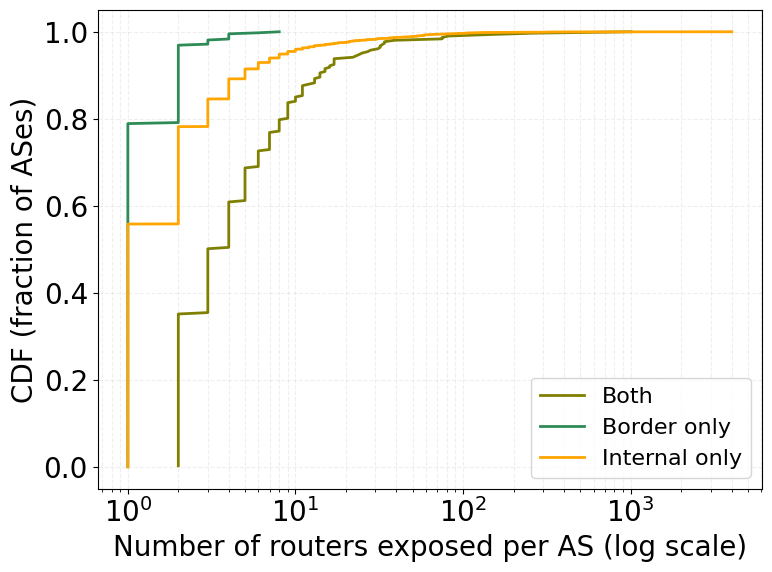

In [13]:

import matplotlib.pyplot as plt
import numpy as np

# plt.rcParams.update({'font.size': 20, 'font.family': 'sans-serif'})

fig, ax = plt.subplots(figsize=(8,6))

# Keep only Internal-only and Border-only
# Keep only Internal and Border
# exposure_types = ['Internal', 'Border']
color_map = {
    'Internal only': '#FFA500',
    'Border only': '#2E8B57',
    'Both': '#808000' 
}

# Update dataframe values
df_asn['exposure_type'] = df_asn['exposure_type'].replace({
    'both': 'Both'
})

# Compute and plot CDF for each type
for exposure_type in df_asn['exposure_type'].unique():
    subset = df_asn[df_asn['exposure_type'] == exposure_type]
    # Sum of routers per AS can also be separated if you like; here we take total
    counts = subset['non_border_count'] + subset['border_count']
    sorted_counts = np.sort(counts)
    cdf = np.arange(1, len(sorted_counts)+1) / len(sorted_counts)
    ax.plot(sorted_counts, cdf, label=exposure_type, color=color_map[exposure_type], lw=2)

# Log scale for skewed distributions
ax.set_xscale('log')

# Labels and title
ax.set_xlabel("Number of routers exposed per AS (log scale)")
ax.set_ylabel("CDF (fraction of ASes)")
# ax.set_title("CDF of Router Exposure Across AS Types")

# Legend with updated title
# ax.legend(title="Router Type")
ax.legend()

# Grid
ax.grid(True, which="both", ls="--", alpha=0.2)

plt.tight_layout()
plt.savefig("images/router_exposure_cdf.pdf")
# plt.show()


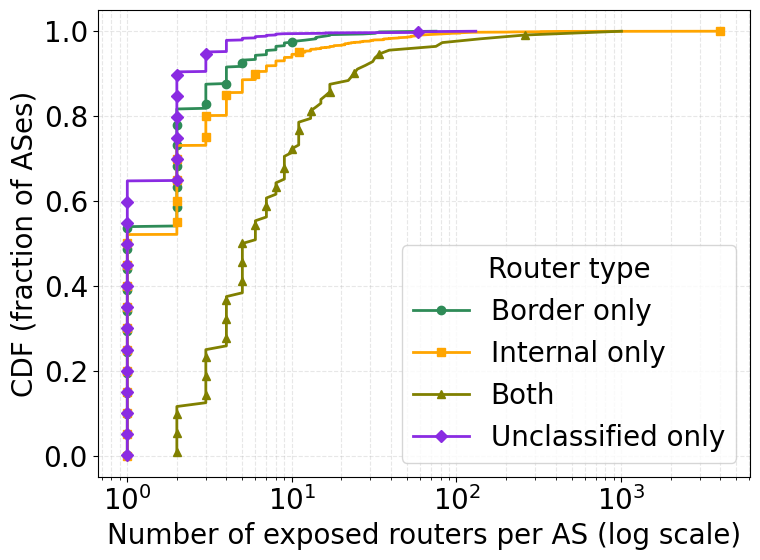

In [14]:
# 1. Unclassified routers (previously misnamed as non_border_public)
# Border routers
df_border = public_asn_df[public_asn_df["router_key"].isin(border_routers)]

# Unclassified (public, non-border)
df_unclassified = public_asn_df[public_asn_df["router_key"].isin(non_border_public_routers)]

# Internal (private ASN routers)
df_internal = private_asn_df[private_asn_df["router_key"].isin(non_border_private_routers)]


# 2. Count routers per ASN per type
border_counts = df_border.groupby("effective_asn")["router_key"].nunique()
internal_counts = df_internal.groupby("effective_asn")["router_key"].nunique()
unclassified_counts = df_unclassified.groupby("effective_asn")["router_key"].nunique()

# Combine into one DataFrame
df_asn = pd.DataFrame({
    "border_count": border_counts,
    "internal_count": internal_counts,
    "unclassified_count": unclassified_counts
}).fillna(0)

def classify_exposure(row):
    has_border = row["border_count"] > 0
    has_internal = row["internal_count"] > 0
    has_unclassified = row["unclassified_count"] > 0

    if has_border and has_internal:
        return "Both"
    elif has_border:
        return "Border only"
    elif has_internal:
        return "Internal only"
    else:
        return "Unclassified only"

df_asn["exposure_type"] = df_asn.apply(classify_exposure, axis=1)

color_map = {
    'Internal only': '#FFA500',
    'Border only': '#2E8B57',
    'Both': '#808000',
    'Unclassified only': '#8A2BE2'  # new color
}

subset = df_asn[df_asn['exposure_type'] == exposure_type].copy()

counts = (
    subset['internal_count'] +
    subset['border_count'] +
    subset['unclassified_count']
)

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({'font.size': 20, 'font.family': 'sans-serif'})

fig, ax = plt.subplots(figsize=(8,6))

# Colors and markers
color_map = {
    'Border only': '#2E8B57',
    'Internal only': '#FFA500',
    'Both': '#808000',
    'Unclassified only': '#8A2BE2'
}

marker_map = {
    'Border only': 'o',
    'Internal only': 's',
    'Both': '^',
    'Unclassified only': 'D'
}

legend_order = ['Border only', 'Internal only', 'Both', 'Unclassified only']

# Ensure numeric
for col in ['border_count', 'internal_count', 'unclassified_count']:
    df_asn[col] = pd.to_numeric(df_asn[col], errors='coerce').fillna(0)

for exposure_type in legend_order:
    if exposure_type in df_asn['exposure_type'].unique():
        subset = df_asn[df_asn['exposure_type'] == exposure_type].copy()
        counts = subset[['border_count','internal_count','unclassified_count']].sum(axis=1)
        counts = counts[counts > 0]

        sorted_counts = np.sort(counts)
        cdf = np.arange(1, len(sorted_counts)+1) / len(sorted_counts)

        ax.plot(
            sorted_counts,
            cdf,
            label=exposure_type,
            color=color_map.get(exposure_type, 'black'),
            lw=2,
            marker=marker_map.get(exposure_type, 'o'),
            markevery=max(len(sorted_counts)//20,1)  # plot markers sparsely
        )

ax.set_xscale('log')
ax.set_xlabel("Number of exposed routers per AS (log scale)")
ax.set_ylabel("CDF (fraction of ASes)")
ax.legend(title="Router type")
ax.grid(True, which="both", ls="--", alpha=0.3)

plt.tight_layout()

plt.savefig("images/router_exposure_cdf_by_type.pdf")
plt.show()

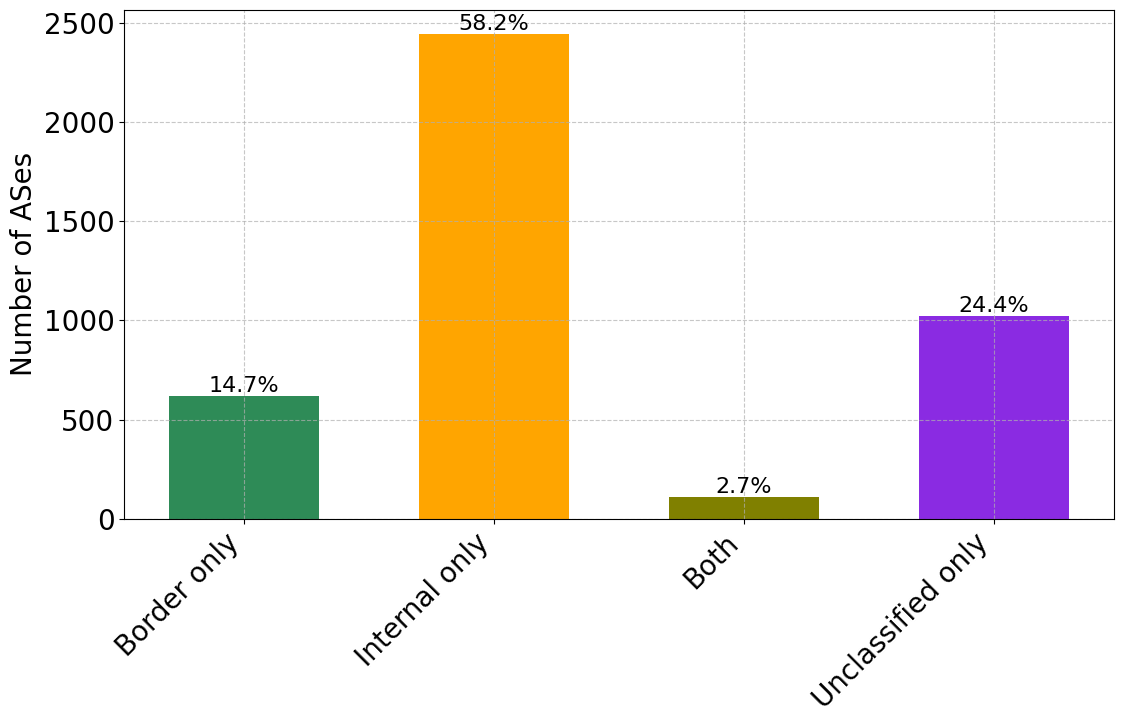

In [20]:
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 32})
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
# Increase figure height for better bar visibility
plt.figure(figsize=(12,8 ))  # Taller figure


# Desired order
order = ['Border only', 'Internal only', 'Both', 'Unclassified only']

# Colors
colors = {
    'Border only': '#2E8B57',
    'Internal only': '#FFA500',
    'Both': '#808000',
    'Unclassified only': '#8A2BE2'
}

asn_counts = df_asn['exposure_type'].value_counts()
# Convert to percentages
asn_percent = 100 * asn_counts / asn_counts.sum()

# Plot bars
bars = plt.bar(
    order,
    [asn_counts.get(o, 0) for o in order],
    color=[colors[o] for o in order],
    width=0.6  # narrower bars so spacing looks better
)

# Add percentages on top
for bar, perc in zip(bars, [asn_percent.get(o, 0) for o in order]):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),  # slight offset above bar
        f"{perc:.1f}%",
        ha='center',
        va='bottom',
        fontsize=16
    )

# Axis labels
plt.ylabel("Number of ASes")
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.7)

# Layout and save
plt.tight_layout()
plt.savefig('images/exposure_type_plot.pdf')
plt.show()

In [29]:
# Compute fraction of border, internal, unclassified routers per AS:
df_asn['total'] = df_asn['border_count'] + df_asn['internal_count'] + df_asn['unclassified_count']
df_asn['frac_border'] = df_asn['border_count'] / df_asn['total']
df_asn['frac_internal'] = df_asn['internal_count'] / df_asn['total']
df_asn['frac_unclassified'] = df_asn['unclassified_count'] / df_asn['total']

# Then for ASes in Both exposure type, you can plot CDFs of fractions:
both_as = df_asn[df_asn['exposure_type'] == 'Both']
for col, label in zip(['frac_border','frac_internal','frac_unclassified'],
                      ['Border fraction','Internal fraction','Unclassified fraction']):
    sorted_vals = np.sort(both_as[col])
    cdf = np.arange(1,len(sorted_vals)+1)/len(sorted_vals)
    ax.plot(sorted_vals, cdf, label=label)

Total routers we found are 8871 and details are:
      enterprise  num_routers
0   9.000000e+00           25
1   2.007000e+03         2956
2   2.011000e+03            9
3   2.636000e+03         5448
4   3.902000e+03            1
5   8.072000e+03           32
6   1.498800e+04           87
7   1.908874e+07           88
8   3.054199e+08          207
9   8.084644e+08            2
10  1.970372e+09           13
11  1.970372e+09            2
12  1.970373e+09            1


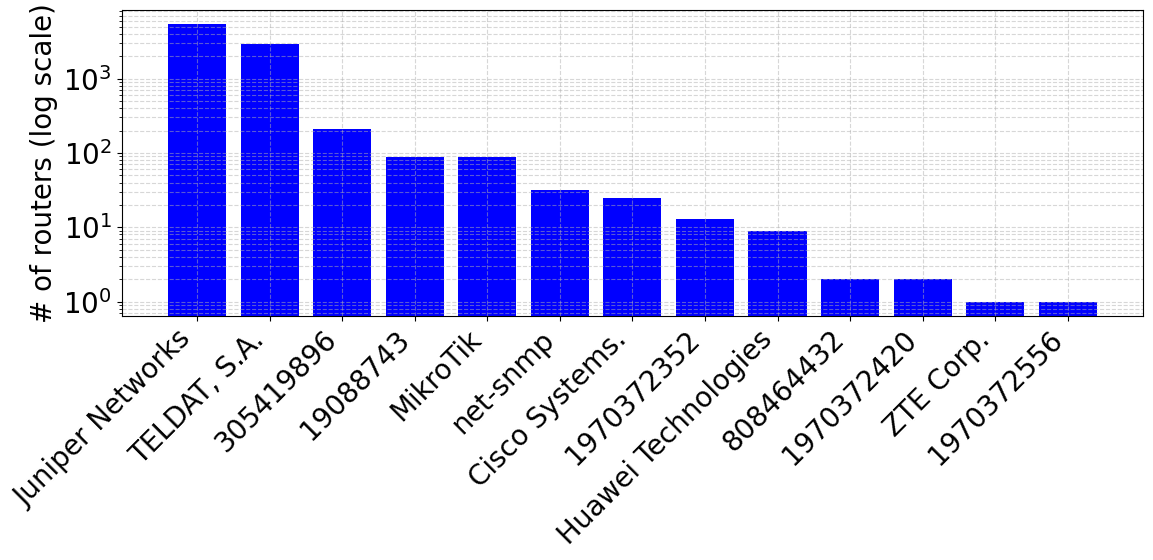

In [30]:
# Shodan query to get vendor information routers for open-responder
shodan_vendor = pd.read_csv("data/shodan_snmp_results_open_keepalive_notification_only_02_feb_bonaire_router_mapping.csv")
shodan_vendor_with_enterprise = shodan_vendor[~shodan_vendor["enterprise"].isna()]

merged_public_private_df = pd.concat([
    public_asn_df,
    private_asn_df
], ignore_index=True)

merged_vendor_patterns = pd.merge(
    merged_public_private_df,
    shodan_vendor_with_enterprise,
    left_on='target_ip',
    right_on='ip',
    how='left'
)


# Count the number of unique routers per vendor
routers_per_vendor = merged_vendor_patterns.groupby('enterprise')['router_id'].nunique().reset_index()
routers_per_vendor = routers_per_vendor.rename(columns={'router_id': 'num_routers'})
print("Total routers we found are %s and details are:\n%s" % (
    routers_per_vendor['num_routers'].sum(),
    routers_per_vendor
))

# ---------- IEEE-style global settings ----------
plt.rcParams.update({
    'font.size': 20,
    'axes.labelsize': 20,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
})
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

# Known vendor names (unknowns as None for now)
enterprise_numbers = routers_per_vendor['enterprise']
vendor_names = [
    "Cisco Systems.",
    "TELDAT, S.A.",
    "Huawei Technologies",
    "Juniper Networks",
    "ZTE Corp.",
    "net-snmp",
    None,
    None,
    None,
    None,
    None,
    None,
    None
]

# Replace None with the enterprise number itself
vendor_names = [name if name is not None else str(num) 
                for num, name in zip(enterprise_numbers, vendor_names)]

# Create the mapping dataframe
enterprise_mapping_df = pd.DataFrame({
    'enterprise': enterprise_numbers,
    'enterprise_name_mapped': vendor_names
})

# Ensure 'enterprise' column in both dataframes is i2636nteger
routers_per_vendor['enterprise'] = routers_per_vendor['enterprise'].astype(int)
enterprise_mapping_df['enterprise'] = enterprise_mapping_df['enterprise'].astype(int)

# Merge again
routers_with_names = pd.merge(
    routers_per_vendor,
    enterprise_mapping_df,
    on='enterprise',
    how='left'
)

# Keep only the mapped enterprise name and number of routers
routers_with_names = routers_with_names[['enterprise_name_mapped', 'num_routers']]

# Optionally, rename the column to something clean
routers_with_names = routers_with_names.rename(columns={'enterprise_name_mapped': 'enterprise_name'})


# Convert enterprise_name column to int if it’s numeric, then to string
routers_with_names['enterprise_name'] = routers_with_names['enterprise_name'].apply(
    lambda x: str(int(x)) if isinstance(x, float) else str(x)
)

# Display the final result
import matplotlib.pyplot as plt

# Map known enterprise numbers to names (add MikroTik as an example)
enterprise_name_map = {
    14988: "MikroTik",
    # Add more mappings here if needed
}

def clean_enterprise_name(x):
    if x is None:
        return "Unknown"

    # Convert to string for safe processing
    x_str = str(x)

    # If numeric, normalize it
    try:
        num = int(float(x_str))
        if num in enterprise_name_map:
            return enterprise_name_map[num]
        return str(num)  # removes .0
    except ValueError:
        return x_str  # already a vendor name

routers_with_names['enterprise_name'] = routers_with_names['enterprise_name'].apply(clean_enterprise_name)


# Sort by number of routers descending for better visualization
routers_plot = routers_with_names.sort_values(by='num_routers', ascending=False)

# Plot
plt.figure(figsize=(12, 6))
plt.bar(routers_plot['enterprise_name'], routers_plot['num_routers'], color='blue')
plt.xticks(rotation=45, ha='right')  # Rotate names for readability
# plt.xlabel('Enterprise Name')
plt.ylabel('# of routers (log scale)')
plt.yscale('log')
# plt.title('# of routers per enterprise/vendor')
plt.grid(True, which='both', linestyle='--', alpha=0.5)

plt.tight_layout()  # Adjust layout to prevent clipping of labels
plt.savefig("images/router_vendors.pdf")
plt.show()



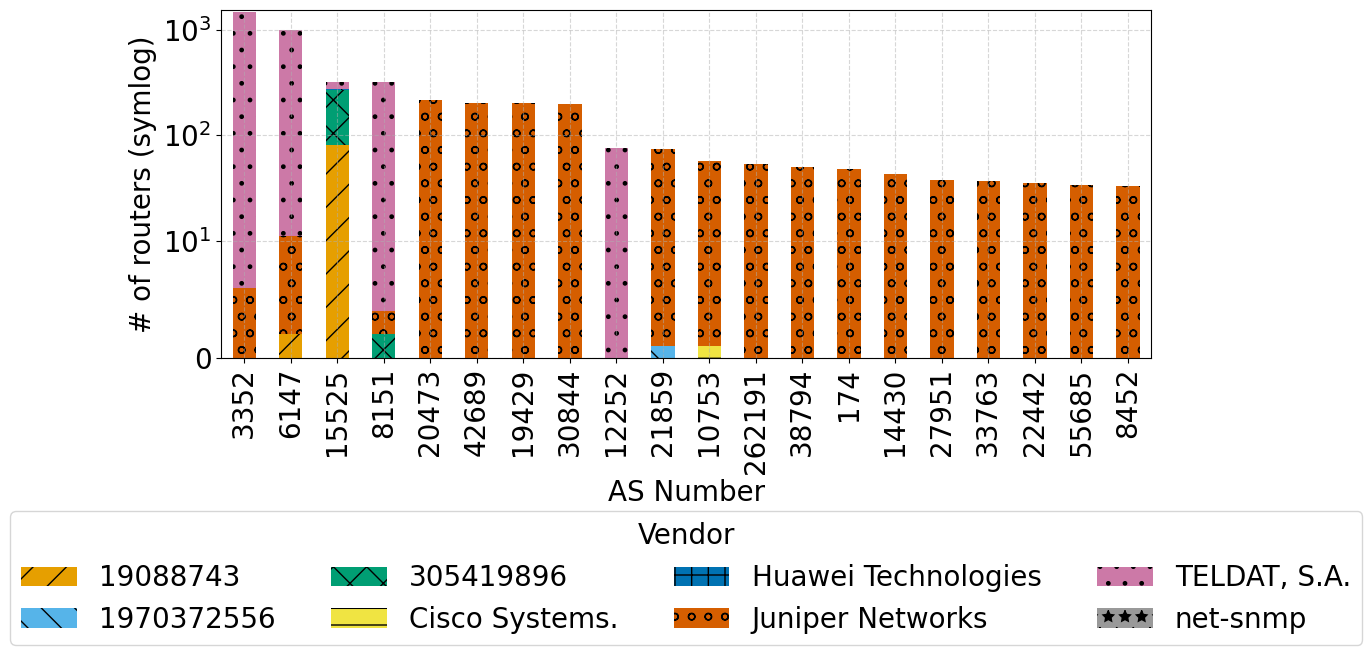

In [33]:
# Plot vendor distribution across top 20 ASes
# Get top 20 ASes by total routers
# Ensure effective_asn is int
import matplotlib.pyplot as plt

colors = [
    "#E69F00", "#56B4E9", "#009E73", "#F0E442",
    "#0072B2", "#D55E00", "#CC79A7", "#999999"
]

hatches = ['/', '\\', 'x', '-', '+', 'o', '.', '*']

# --- Top 20 ASNs by router count ---
top_asns = (
    as_totals
    .sort_values("num_routers", ascending=False)
    .head(20)["effective_asn"]
)

# --- Filter vendor counts for those ASNs ---
top_vendor_asn_counts = vendor_asn_counts[
    vendor_asn_counts["effective_asn"].isin(top_asns)
].copy()

# Ensure ASN is integer
top_vendor_asn_counts["effective_asn"] = top_vendor_asn_counts["effective_asn"].astype(int)

# --- Pivot for stacked plot ---
pivot_df = top_vendor_asn_counts.pivot_table(
    index="effective_asn",
    columns="enterprise_name",
    values="num_routers",
    fill_value=0
)

# Ensure AS order follows router totals
pivot_df = pivot_df.loc[top_asns.astype(int)]

# Remove trailing .0 from columns that look like numbers
pivot_df.columns = [
    str(int(float(c))) if c.replace('.','',1).isdigit() else c 
    for c in pivot_df.columns
]

# --- Plot ---
ax = pivot_df.plot(
    kind="bar",
    stacked=True,
    figsize=(12,6),
    color=colors
)

# Apply hatches
for i, container in enumerate(ax.containers):
    for bar in container:
        bar.set_hatch(hatches[i % len(hatches)])

plt.xlabel("AS Number")
plt.ylabel("# of routers (symlog)")
plt.yscale("symlog", linthresh=10)

ax.legend(
    title="Vendor",
    bbox_to_anchor=(0.5, -0.40),
    ncols=4,
    loc="upper center"
)

plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.subplots_adjust(bottom=0.3)

plt.savefig("images/vendor_across_ases.pdf", bbox_inches="tight")
plt.show()

In [21]:
import pandas as pd

# --- Load data ---
public_asn_df = pd.read_csv("results/public_asn_ips.csv")
private_asn_df = pd.read_csv("results/private_asn_ips_v2.csv")

# --- Filter public ASNs (exclude BGP OPEN) ---
filtered_public = public_asn_df[public_asn_df["asn_from_target_ip"] != public_asn_df["asn"]]

# --- Border routers (more than 1 ASN) ---
asn_counts = filtered_public.groupby("router_key")["asn_from_target_ip"].nunique().reset_index(name="unique_asn_count")
border_router_public = asn_counts[asn_counts["unique_asn_count"] > 1]
border_keys = border_router_public["router_key"]
border_asns = filtered_public[filtered_public["router_key"].isin(border_keys)]["asn_from_target_ip"]

# --- Non-border routers with public ASN ---
non_border_routers = asn_counts[asn_counts["unique_asn_count"] == 1]
non_border_with_asn = non_border_routers.merge(
    public_asn_df[["router_key", "asn_from_target_ip", "is_non_public_asn"]],
    on="router_key",
    how="left"
).drop_duplicates(subset=["router_key", "asn_from_target_ip"])
non_border_public = non_border_with_asn[non_border_with_asn["is_non_public_asn"] == False]
non_border_keys = non_border_public["router_key"]
non_border_asns = filtered_public[filtered_public["router_key"].isin(non_border_keys)]["asn_from_target_ip"]

# --- Private ASN routers ---
private_asn_routers = private_asn_df.drop_duplicates(subset=["router_key", "asn_from_target_ip"])
private_keys = private_asn_routers["router_key"]
private_asns = private_asn_routers["asn_from_target_ip"]

# --- Union of ASNs across all three groups ---
all_unique_asns = pd.concat([border_asns, non_border_asns, private_asns]).unique()
total_unique_asns = len(all_unique_asns)

print(f"Total unique ASNs across all three groups: {total_unique_asns}")

Total unique ASNs across all three groups: 3484


In [38]:
'''
Compare our method of finding border router with CAIDA AS rank data


# Pyrank API
# Method to get AS rank of all ASes from CAIDA AS rank API
# This part of the code is used from https://github.com/bgpkit/pyasrank
import json
import logging
from datetime import datetime

import requests
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry

ASRANK_ENDPOINT = "https://api.asrank.caida.org/v2/graphql"


def ts_to_date_str(ts):
    """
    Convert timestamp to a date. This is used for ASRank API which only takes
    date strings with no time as parameters.api
    """
    return datetime.utcfromtimestamp(int(ts)).strftime("%Y-%m-%d")


class AsRank:
    """
    Utilities for using ASRank services
    """

    def __init__(self, max_ts=""):
        self.data_ts = None

        # various caches to avoid duplicate queries
        self.cache = None
        self.cone_cache = None
        self.neighbors_cache = None
        self.siblings_cache = None
        self.organization_cache = None

        self.queries_sent = 0

        self.session = None
        self._initialize_session()

        self.init_cache(max_ts)

    def _initialize_session(self):
        self.session = requests.Session()
        retries = Retry(total=5,
                        backoff_factor=1,
                        status_forcelist=[500, 502, 503, 504])
        self.session.mount(ASRANK_ENDPOINT, HTTPAdapter(max_retries=retries))

    def _close_session(self):
        if self.session:
            self.session.close()

    def _send_request(self, query):
        """
        send requests to ASRank endpoint
        :param query:
        :return:
        """

        r = self.session.post(url=ASRANK_ENDPOINT, json={'query': query})
        r.raise_for_status()
        self.queries_sent += 1
        return r

    def init_cache(self, ts):
        """
        Initialize the ASRank cache for the timestamp ts
        :param ts:
        :return:
        """
        self.cache = {}
        self.cone_cache = {}
        self.neighbors_cache = {}
        self.siblings_cache = {}
        self.organization_cache = {}
        self.queries_sent = 0
        if isinstance(ts, int):
            ts = ts_to_date_str(ts)
8755
        ####
        # Try to cache datasets available before the given ts
        ####
        graphql_query = """
            {
              datasets(dateStart:"2000-01-01", dateEnd:"%s", sort:"-date", first:1){
                edges {
                  node {
                    date
                  }
                }
              }
            }
        """ % ts
        r = self._send_request(graphql_query)

        edges = r.json()['data']['datasets']['edges']
        if edges:
            self.data_ts = edges[0]["node"]["date"]
            return

        # if code reaches here, we have not found any datasets before ts. we should now try to find one after ts.
        # this is the best effort results
        logging.warning("cannot find dataset before date %s, looking for the closest one after it now" % ts)

        graphql_query = """
            {
              datasets(dateStart:"%s", sort:"date", first:1){
                edges {
                  node {
                    date
                  }
                }
              }
            }
        """ % ts
        r = self._send_request(graphql_query)
        edges = r.json()['data']['datasets']['edges']
        if edges:
            self.data_ts = edges[0]["node"]["date"]
            logging.warning("found closest dataset date to be %s" % self.data_ts)
            return
        else:
            raise ValueError("no datasets from ASRank available to use for tagging")

    def _query_asrank_for_asns(self, asns, chunk_size=100):
        asns = [str(asn) for asn in asns]
        asns_needed = [asn for asn in asns if asn not in self.cache]
        if not asns_needed:
            return

        # https://stackoverflow.com/a/312464/768793
        def chunks(lst, n):
            """Yield successive n-sized chunks from lst."""
            for i in range(0, len(lst), n):
                yield lst[i:i + n]

        for asns in chunks(asns_needed, chunk_size):

            graphql_query = """
                {
                  asns(asns: %s, dateStart: "%s", dateEnd: "%s", first:%d, sort:"-date") {
                    edges {
                      node {
                        date
                        asn
                        asnName
                        rank
                        organization{
                          country{
                            iso
                            name
                          }
                          orgName
                          orgId
                        } asnDegree {
                          provider
                          peer
                          customer
                          total
                          transit
                          sibling
                        }
                      }
                    }
                  }
                }
            """ % (json.dumps(asns), self.data_ts, self.data_ts, len(asns))
            r = self._send_request(graphql_query)
            try:
                for node in r.json()['data']['asns']['edges']:
                    data = node['node']
                    if data['asn'] not in self.cache:
                        if "asnDegree" in data:
                            degree = data["asnDegree"]
                            degree["provider"] = degree["provider"] or 0
                            degree["customer"] = degree["customer"] or 0
                            degree["peer"] = degree["peer"] or 0
                            degree["sibling"] = degree["sibling"] or 0
                            data["asnDegree"] = degree
                        self.cache[data['asn']] = data
                for asn in asns:
                    if asn not in self.cache:
                        self.cache[asn] = None
            except KeyError as e:
                logging.error("Error in node: {}".format(r.json()))
                logging.error("Request: {}".format(graphql_query))
                raise e

    ###########
    # AS_RANK #
    ###########

    def get_relationship(self, asn0, asn1):
        """
        Get the AS relationship between asn0 and asn1.

        asn0 is asn1's:
        - provider: "p-c"
        - customer: "c-p"
        - peer: "p-p"
        - other: None

        :param asn0:
        :param asn1:
        :return:
        """
        graphql_query = """
            {
              asnLink(asn0:"%s", asn1:"%s", date:"%s"){
              relationship
              }
            }
        """ % (asn0, asn1, self.data_ts)
        r = self._send_request(graphql_query)
        if r.json()["data"]["asnLink"] is None:
            return None
        rel = r.json()["data"]["asnLink"].get("relationship", "")

        if rel == "provider":
            # asn1 is the provider of asn0
            return "c-p"

        if rel == "customer":
            # asn1 is the customer of asn0
            return "p-c"

        if rel == "peer":
            # asn1 is the peer of asn0
            return "p-p"

        return None
 



import csv

# Assuming AsRank class is imported and available
as_rank = AsRank()

# Convert the Pandas Series to a dictionary where values are lists of ASNs
covered_asns_per_router_dict = covered_asns_per_router.apply(list).to_dict()
# covered_asns_per_router_dict = {
#     "0.0.0.0_56258": [56258, 58463, 149696],
#     "0.0.0.0_60042": [60042, 9049, 20485],
# }

results = []
matched_count = 0
total_checks = 0

for router, asn_list in covered_asns_per_router_dict.items():
    if not asn_list:
        continue
    
    main_asn = int(asn_list[0])  # first ASN as reference
    
    for sibling_asn in asn_list[1:]:
        sibling_asn = int(sibling_asn)
        total_checks += 1
        relationship = as_rank.get_relationship(main_asn, sibling_asn)
        is_match = bool(relationship)
        if is_match:
            matched_count += 1
        
        results.append({
            "router": router,
            "main_asn": main_asn,
            "sibling_asn": sibling_asn,
            "match": is_match
        })

# Save to CSV
csv_file = "results/asn_relationships.csv"
with open(csv_file, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=["router", "main_asn", "sibling_asn", "match"])
    writer.writeheader()
    writer.writerows(results)

print(f"Total relationships checked: {total_checks}")
print(f"Total matches found: {matched_count}")
print(f"Results saved to {csv_file}")
'''

'\nCompare our method of finding border router with CAIDA AS rank data\n\n\n# Pyrank API\n# Method to get AS rank of all ASes from CAIDA AS rank API\n# This part of the code is used from https://github.com/bgpkit/pyasrank\nimport json\nimport logging\nfrom datetime import datetime\n\nimport requests\nfrom requests.adapters import HTTPAdapter\nfrom urllib3.util.retry import Retry\n\nASRANK_ENDPOINT = "https://api.asrank.caida.org/v2/graphql"\n\n\ndef ts_to_date_str(ts):\n    """\n    Convert timestamp to a date. This is used for ASRank API which only takes\n    date strings with no time as parameters.api\n    """\n    return datetime.utcfromtimestamp(int(ts)).strftime("%Y-%m-%d")\n\n\nclass AsRank:\n    """\n    Utilities for using ASRank services\n    """\n\n    def __init__(self, max_ts=""):\n        self.data_ts = None\n\n        # various caches to avoid duplicate queries\n        self.cache = None\n        self.cone_cache = None\n        self.neighbors_cache = None\n        self.si